# Model 2: Contextual Bandit for Retention Action Selection

This notebook implements the contextual-bandit model described in **Section 4** of the methodology report and demonstrates learning following the **Section 7** proof-of-concept protocol.

**Architecture:**
- Ridge reward model per action: $\hat{\mu}_a(x) = \theta_a^\top x$
- Cumulative closed-form refit each month
- $\varepsilon$-greedy exploration with decay
- Actions: $\mathcal{A} = \{\text{no\_action},\; \text{push\_notification},\; \text{email},\; \text{call}\}$
- Reward (EUR): $R_i = (1 - Y_i)\,v_i - c(A_i)$ where $v_i$ is annual customer revenue

**Key demonstration goal:**
- All 4 actions are available from month 1 — the model starts knowing nothing.
- Over 24 months, the model learns **which action is best for each customer** based on accumulated data.
- We track cumulative **revenue saved** (EUR) vs the no-action baseline to show the business impact.

In [100]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.ndimage import gaussian_filter
from collections import defaultdict

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

SEED = 42
np.random.seed(SEED)

## 1. Load and prepare the bandit training dataset

In [101]:
df = pd.read_csv("../data/output/bandit_training_dataset.csv")
df["reference_date"] = pd.to_datetime(df["reference_date"])
df["reference_month"] = df["reference_date"].dt.to_period("M").dt.to_timestamp()
df = df.sort_values(["reference_month", "client_id"]).reset_index(drop=True)

print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Date range: {df['reference_date'].min().date()} → {df['reference_date'].max().date()}")
print(f"Unique customers: {df['client_id'].nunique():,}")
print(f"Monthly batches: {df['reference_month'].nunique()}")

Dataset: 60,000 rows, 33 columns
Date range: 2024-05-01 → 2026-04-30
Unique customers: 7,805
Monthly batches: 24


In [102]:
# Feature columns used as context vector x_i
FEATURE_COLS = [
    "tenure_years", "n_products", "has_loan", "receives_salary",
    "avg_txn_per_month", "avg_txn_amount", "txn_trend",
    "avg_balance", "balance_trend", "n_contacts",
    "age", "credit_rating", "has_deposit", "digital_txn_ratio",
    "debit_credit_ratio", "balance_volatility", "txn_amount_std",
    "recency_days", "n_complaint_contacts", "avg_product_age_years",
]

ACTIONS = ["no_action", "push_notification", "email", "call"]
ACTION_TO_IDX = {a: i for i, a in enumerate(ACTIONS)}
ACTION_COSTS = {"no_action": 0.0, "push_notification": 0.50, "email": 8.0, "call": 80.0}
N_ACTIONS = len(ACTIONS)

# Ground-truth expected reward columns (from data generation)
ER_COLS = ["er_no_action", "er_push_notification", "er_email", "er_call"]

print(f"Features (d={len(FEATURE_COLS)}): {FEATURE_COLS[:5]} ... {FEATURE_COLS[-3:]}")
print(f"Actions: {ACTIONS}")
print(f"Costs (EUR): {ACTION_COSTS}")

# Verify ground truth columns exist
assert all(c in df.columns for c in ER_COLS), "Missing expected reward columns"
print(f"\nGround-truth expected rewards available for exact counterfactual evaluation ✓")

# Show risk-value correlation
corr = df[["churn_risk_score", "customer_value_score"]].corr().iloc[0, 1]
print(f"Risk-Value correlation: {corr:.3f}")

# Action distribution in logged data
print(f"\nLogged action distribution:")
print(df["action"].value_counts().to_string())
print(f"Call observations: {(df['action']=='call').sum():,} / {len(df):,} ({(df['action']=='call').mean():.1%})")

Features (d=20): ['tenure_years', 'n_products', 'has_loan', 'receives_salary', 'avg_txn_per_month'] ... ['recency_days', 'n_complaint_contacts', 'avg_product_age_years']
Actions: ['no_action', 'push_notification', 'email', 'call']
Costs (EUR): {'no_action': 0.0, 'push_notification': 0.5, 'email': 8.0, 'call': 80.0}

Ground-truth expected rewards available for exact counterfactual evaluation ✓
Risk-Value correlation: -0.253

Logged action distribution:
action
email                18241
call                 15004
no_action            14259
push_notification    12496
Call observations: 15,004 / 60,000 (25.0%)


In [103]:
# Standardize base features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_base = scaler.fit_transform(df[FEATURE_COLS].values)

def rank_norm(arr):
    """Rank-normalize to [0, 1]."""
    order = np.argsort(np.argsort(arr)).astype(float)
    return order / max(len(arr) - 1, 1)

# Core derived features
risk = df["churn_risk_score"].values.reshape(-1, 1)
value = df["customer_value_score"].values.reshape(-1, 1)
risk_x_value = risk * value

# HTE-relevant proxies (same computation as data generation)
digital_proxy = rank_norm(df["digital_txn_ratio"].values).reshape(-1, 1)
rel_raw = (np.clip(df["tenure_years"].values / 30, 0, 1) * 0.4 +
           np.clip(df["n_products"].values / 8, 0, 1) * 0.35 +
           df["receives_salary"].values.astype(float) * 0.25)
relationship_proxy = rank_norm(rel_raw).reshape(-1, 1)
value_x_digital = value * digital_proxy
value_x_relationship = value * relationship_proxy

derived = np.hstack([risk, value, risk_x_value,
                     digital_proxy, relationship_proxy,
                     value_x_digital, value_x_relationship])
scaler_derived = StandardScaler()
X_derived = scaler_derived.fit_transform(derived)

# Combine: [bias, base_features, derived]
X_all = np.hstack([np.ones((X_base.shape[0], 1)), X_base, X_derived])
d = X_all.shape[1]
print(f"Context dimension: d = {d}  (1 bias + {len(FEATURE_COLS)} base + 7 derived)")

Context dimension: d = 28  (1 bias + 20 base + 7 derived)


## 2. Contextual Bandit Implementation

Linear reward model per action with cumulative Ridge regression and **cost-aware regularization**, as described in Sections 4–7 of the report.

In [104]:
class RidgeContextualBandit:
    """
    Contextual bandit with Ridge regression per action and ε-greedy exploration.
    
    Per-action reward model:  μ̂_a(x) = θ_a^T x
    Trained via Ridge (closed-form) on cumulative data, refitted each month.
    
    Cost-aware regularization: α_a = α_base + cost_reg_scale × cost(a).
    Expensive actions (calls) get stronger L2 penalty initially, requiring
    more evidence before they are recommended. This decays each month.
    """
    
    def __init__(self, n_actions, d, alpha=1.0, epsilon=0.25,
                 epsilon_decay=0.97, epsilon_min=0.02,
                 action_costs=None, cost_reg_scale=0.0, cost_reg_decay=0.85):
        self.n_actions = n_actions
        self.d = d
        self.alpha = alpha
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        
        # Cost-aware regularization
        self.action_costs = action_costs if action_costs is not None else [0.0] * n_actions
        self.cost_reg_scale = cost_reg_scale
        self.cost_reg_decay = cost_reg_decay
        
        # Per-action parameter vectors
        self.theta = np.zeros((n_actions, d))
        
        # Cumulative sufficient statistics: X^T X and X^T r for each action
        self.XtX = [np.zeros((d, d)) for _ in range(n_actions)]
        self.Xtr = [np.zeros(d) for _ in range(n_actions)]
        self.n_samples = np.zeros(n_actions, dtype=int)
    
    def add_batch(self, X_batch, actions, rewards):
        """Add a batch of observations and update sufficient statistics."""
        for a in range(self.n_actions):
            mask = actions == a
            if mask.sum() == 0:
                continue
            Xa = X_batch[mask]
            ra = rewards[mask]
            self.XtX[a] += Xa.T @ Xa
            self.Xtr[a] += Xa.T @ ra
            self.n_samples[a] += mask.sum()
    
    def refit(self):
        """Refit Ridge for each action with cost-aware regularization."""
        for a in range(self.n_actions):
            if self.n_samples[a] >= self.d:
                # Cost-proportional regularization: expensive actions need more evidence
                alpha_a = self.alpha + self.cost_reg_scale * self.action_costs[a]
                A = self.XtX[a] + alpha_a * np.eye(self.d)
                self.theta[a] = np.linalg.solve(A, self.Xtr[a])
    
    def predict_rewards(self, x):
        """Predict expected reward for each action given context x."""
        return self.theta @ x
    
    def select_action(self, x, explore=True):
        """ε-greedy action selection."""
        if explore and np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.predict_rewards(x)))
    
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
    
    def decay_cost_reg(self):
        """Decay cost regularization — lets the model trust expensive actions more over time."""
        self.cost_reg_scale *= self.cost_reg_decay

print("RidgeContextualBandit defined ✓ (with cost-aware regularization)")

RidgeContextualBandit defined ✓ (with cost-aware regularization)


## 3. Time-ordered training loop

We process the dataset **chronologically by monthly batch**, simulating the operational pipeline:
1. For each month: add observed (action, reward) pairs to cumulative data, refit Ridge
2. After refit: evaluate current policy using **ground-truth expected rewards**  
3. Ground truth: dataset contains $E[R(a)] = (1-p(a)) \cdot v - c(a)$ for all actions (in EUR)
4. This gives us exact counterfactual evaluation — no need for matched/IPS estimation

All 4 actions are available from month 1 — we track how the model gradually learns.

In [105]:
# ── Hyperparameters ──
ALPHA = 1.0              # Ridge base regularization
EPSILON_START = 0.25
EPSILON_DECAY = 0.90     # per month (faster decay = less exploration)
EPSILON_MIN = 0.02

# Cost-aware regularization: expensive actions (calls €80) are suppressed
# initially and gradually "unlock" as the model gathers evidence they work.
COST_REG_SCALE = 1.0     # initial cost regularization multiplier (high → strong call suppression)
COST_REG_DECAY = 0.85    # monthly decay rate

# ── Progressive call introduction ──
# In a real deployment, you wouldn't start making €80 calls on day 1.
# The model must first learn from cheap actions (push/email) to build a
# baseline, then gradually test calls as evidence accumulates.
CALL_GATE_MONTHS = 10    # months over which call data is linearly introduced
                          # month 0 → 0% call obs, month 10+ → 100%

# Bank scale for revenue projection
BANK_ACCOUNTS = 500_000  # target: Croatian bank with 500k open accounts

# ── Snapshot schedule for temporal analysis ──
SNAPSHOT_MONTHS = list(range(0, 24, 3)) + [23]   # months 0,3,6,...,21,23

# Initialize the bandit
bandit = RidgeContextualBandit(
    n_actions=N_ACTIONS,
    d=d,
    alpha=ALPHA,
    epsilon=EPSILON_START,
    epsilon_decay=EPSILON_DECAY,
    epsilon_min=EPSILON_MIN,
    action_costs=[ACTION_COSTS[a] for a in ACTIONS],
    cost_reg_scale=COST_REG_SCALE,
    cost_reg_decay=COST_REG_DECAY,
)

# ── Metrics storage ──
monthly_metrics = []
theta_history = []
stage_bandits = {}        # {month_idx: deepcopy(bandit)} for temporal analysis

# Monthly batches in chronological order
months = sorted(df["reference_month"].unique())
print(f"Training: 1 pass × {len(months)} months (cumulative Ridge refit each month)")
print(f"  α={ALPHA}, ε₀={EPSILON_START}, ε_decay={EPSILON_DECAY}")
print(f"  Cost-aware reg: scale₀={COST_REG_SCALE}, decay={COST_REG_DECAY}")
print(f"  → α_call month 0 = {ALPHA + COST_REG_SCALE * ACTION_COSTS['call']:,.0f}  "
      f"(calls heavily suppressed initially)")
print(f"  Progressive call gate: 0% call data at month 0, 100% at month {CALL_GATE_MONTHS}")
print(f"  Snapshots at months: {SNAPSHOT_MONTHS}")
print(f"  Bank projection: {BANK_ACCOUNTS:,} accounts")
print("=" * 80)

Training: 1 pass × 24 months (cumulative Ridge refit each month)
  α=1.0, ε₀=0.25, ε_decay=0.9
  Cost-aware reg: scale₀=1.0, decay=0.85
  → α_call month 0 = 81  (calls heavily suppressed initially)
  Progressive call gate: 0% call data at month 0, 100% at month 10
  Snapshots at months: [0, 3, 6, 9, 12, 15, 18, 21, 23]
  Bank projection: 500,000 accounts


In [106]:
# Ground-truth expected rewards matrix for evaluation
ER_matrix = df[ER_COLS].values  # shape (N, 4)

# Pre-compute GLOBAL value deciles for tracking call frequency by customer segment
df["value_decile_global"] = pd.qcut(df["customer_value_score"], 10,
                                     labels=[f"D{i}" for i in range(1, 11)])
TRACKED_DECILES = ["D1", "D5", "D10"]

# Cumulative revenue tracking
cumul_policy_revenue = 0.0
cumul_noaction_revenue = 0.0
cumul_customers = 0

for month_idx, month in enumerate(months):
    batch_mask = df["reference_month"] == month
    batch_indices = df.index[batch_mask].values
    n_batch = len(batch_indices)
    
    # ── Add this month's logged data to the model ──
    X_batch = X_all[batch_indices]
    a_batch = np.array([ACTION_TO_IDX[a] for a in df.loc[batch_indices, "action"]])
    r_batch = df.loc[batch_indices, "reward"].values
    
    # ── Progressive call gate: simulate realistic deployment ──
    # In production, you don't start with €80 calls on day 1.
    # Gradually introduce call observations so the model must LEARN
    # that calls work before it can recommend them.
    if CALL_GATE_MONTHS > 0 and month_idx < CALL_GATE_MONTHS:
        call_frac = month_idx / CALL_GATE_MONTHS  # 0 at month 0, ~1 at gate end
        call_idxs = np.where(a_batch == ACTION_TO_IDX["call"])[0]
        n_keep = int(len(call_idxs) * call_frac)
        if n_keep < len(call_idxs):
            np.random.seed(SEED + month_idx)
            drop = np.random.choice(call_idxs, len(call_idxs) - n_keep, replace=False)
            keep_mask = np.ones(len(a_batch), dtype=bool)
            keep_mask[drop] = False
            X_batch = X_batch[keep_mask]
            a_batch = a_batch[keep_mask]
            r_batch = r_batch[keep_mask]
    
    bandit.add_batch(X_batch, a_batch, r_batch)
    bandit.refit()
    
    # ── Save snapshot for temporal learning analysis ──
    if month_idx in SNAPSHOT_MONTHS:
        stage_bandits[month_idx] = copy.deepcopy(bandit)
    
    eps_before = bandit.epsilon
    cost_reg_before = bandit.cost_reg_scale
    bandit.decay_epsilon()
    bandit.decay_cost_reg()
    
    # ── Evaluate: use ground-truth expected rewards ──
    policy_actions = np.array([
        int(np.argmax(bandit.predict_rewards(X_all[idx])))
        for idx in batch_indices
    ])
    
    # Ground-truth E[R] of the policy's chosen actions
    policy_er = np.array([
        ER_matrix[idx, policy_actions[j]]
        for j, idx in enumerate(batch_indices)
    ])
    avg_policy_er = policy_er.mean()
    
    # Compare to no-action baseline on same batch
    noaction_er = np.array([ER_matrix[idx, 0] for idx in batch_indices])
    avg_noaction_er = noaction_er.mean()
    
    # Revenue tracking (EUR)
    monthly_revenue_policy = policy_er.sum()
    monthly_revenue_noaction = noaction_er.sum()
    monthly_revenue_saved = monthly_revenue_policy - monthly_revenue_noaction
    
    cumul_policy_revenue += monthly_revenue_policy
    cumul_noaction_revenue += monthly_revenue_noaction
    cumul_customers += n_batch
    
    # Action distribution
    action_counts = np.bincount(policy_actions, minlength=N_ACTIONS)
    action_fracs = action_counts / n_batch
    
    # Parameter norms
    theta_norms = [np.linalg.norm(bandit.theta[a]) for a in range(N_ACTIONS)]
    theta_history.append(theta_norms.copy())
    
    # Call data included this month
    call_data_pct = min(1.0, month_idx / CALL_GATE_MONTHS) if CALL_GATE_MONTHS > 0 else 1.0
    
    metrics = {
        "batch": month_idx,
        "month": pd.Timestamp(month),
        "month_idx": month_idx,
        "n_batch": n_batch,
        "epsilon": eps_before,
        "cost_reg_scale": cost_reg_before,
        "alpha_call": ALPHA + cost_reg_before * ACTION_COSTS["call"],
        "call_data_pct": call_data_pct,
        "policy_er": avg_policy_er,
        "noaction_er": avg_noaction_er,
        "improvement_vs_noaction": avg_policy_er - avg_noaction_er,
        "monthly_revenue_saved": monthly_revenue_saved,
        "cumul_revenue_saved": cumul_policy_revenue - cumul_noaction_revenue,
        "cumul_customers": cumul_customers,
    }
    for a_idx, a_name in enumerate(ACTIONS):
        metrics[f"frac_{a_name}"] = action_fracs[a_idx]
        metrics[f"theta_norm_{a_name}"] = theta_norms[a_idx]
    
    # Track call frequency by value decile (D1=lowest, D10=highest)
    batch_vd = df.loc[batch_indices, "value_decile_global"].values
    for vd in TRACKED_DECILES:
        vd_mask = batch_vd == vd
        metrics[f"call_frac_{vd}"] = (policy_actions[vd_mask] == 3).mean() if vd_mask.sum() > 0 else 0.0
    
    monthly_metrics.append(metrics)
    
    # Print progress
    month_str = pd.Timestamp(month).strftime("%Y-%m")
    improvement = avg_policy_er - avg_noaction_er
    alpha_call = ALPHA + cost_reg_before * ACTION_COSTS["call"]
    call_gate_str = f"gate={call_data_pct:.0%}" if month_idx < CALL_GATE_MONTHS else "gate=off"
    print(
        f"  {month_str}  |  "
        f"ε={eps_before:.3f}  "
        f"α_call={alpha_call:>6,.0f}  "
        f"{call_gate_str:>9s}  "
        f"E[R]=€{avg_policy_er:,.0f}  "
        f"Δ=€{improvement:+,.0f}  "
        f"no={action_fracs[0]:.2f} pu={action_fracs[1]:.2f} "
        f"em={action_fracs[2]:.2f} ca={action_fracs[3]:.2f}"
    )

print(f"\n{'='*80}")
print(f"Training complete. {len(months)} months, {cumul_customers:,} customer-months.")
print(f"Cumulative revenue saved vs no_action: €{cumul_policy_revenue - cumul_noaction_revenue:,.0f}")
print(f"Final samples per action: {dict(zip(ACTIONS, bandit.n_samples.astype(int)))}")
print(f"Snapshots saved: {sorted(stage_bandits.keys())}")

  2024-05  |  ε=0.250  α_call=    81    gate=0%  E[R]=€1,537  Δ=€+66  no=0.28 pu=0.36 em=0.36 ca=0.00
  2024-06  |  ε=0.225  α_call=    69   gate=10%  E[R]=€1,539  Δ=€+68  no=0.25 pu=0.32 em=0.41 ca=0.02
  2024-07  |  ε=0.203  α_call=    59   gate=20%  E[R]=€1,503  Δ=€+63  no=0.29 pu=0.24 em=0.43 ca=0.04
  2024-08  |  ε=0.182  α_call=    50   gate=30%  E[R]=€1,525  Δ=€+77  no=0.27 pu=0.20 em=0.42 ca=0.11
  2024-09  |  ε=0.164  α_call=    43   gate=40%  E[R]=€1,512  Δ=€+74  no=0.22 pu=0.14 em=0.45 ca=0.19
  2024-10  |  ε=0.148  α_call=    36   gate=50%  E[R]=€1,505  Δ=€+77  no=0.25 pu=0.14 em=0.38 ca=0.23
  2024-11  |  ε=0.133  α_call=    31   gate=60%  E[R]=€1,538  Δ=€+81  no=0.19 pu=0.15 em=0.35 ca=0.31
  2024-12  |  ε=0.120  α_call=    27   gate=70%  E[R]=€1,531  Δ=€+84  no=0.15 pu=0.17 em=0.39 ca=0.28
  2025-01  |  ε=0.108  α_call=    23   gate=80%  E[R]=€1,563  Δ=€+99  no=0.14 pu=0.22 em=0.39 ca=0.26
  2025-02  |  ε=0.097  α_call=    20   gate=90%  E[R]=€1,530  Δ=€+96  no=0.15 pu=0

In [107]:
mdf = pd.DataFrame(monthly_metrics)
mdf.head()

,batch,month,month_idx,n_batch,epsilon,cost_reg_scale,alpha_call,call_data_pct,policy_er,noaction_er,...,theta_norm_no_action,frac_push_notification,theta_norm_push_notification,frac_email,theta_norm_email,frac_call,theta_norm_call,call_frac_D1,call_frac_D5,call_frac_D10
0,0,2024-05-01,0,2500,0.250000,1.000000,81.0000,0.0,1537.347357,1471.135504,...,2323.455348,0.3612,2633.055141,0.3632,1936.200296,0.0000,0.000000,0.000000,0.000000,0.000000
1,1,2024-06-01,1,2500,0.225000,0.850000,69.0000,0.1,1539.345635,1471.306644,...,2627.341687,0.3208,2375.941087,0.4080,2277.183432,0.0188,735.071938,0.038023,0.004219,0.000000
2,2,2024-07-01,2,2500,0.202500,0.722500,58.8000,0.2,1503.476696,1440.050613,...,2565.023585,0.2420,2410.026647,0.4308,2210.161494,0.0372,1480.764206,0.007812,0.048980,0.061475
3,3,2024-08-01,3,2500,0.182250,0.614125,50.1300,0.3,1524.852753,1448.157133,...,2681.648587,0.1968,2462.658469,0.4236,2393.059569,0.1104,1654.751919,0.152091,0.083665,0.108527
4,4,2024-09-01,4,2500,0.164025,0.522006,42.7605,0.4,1511.817835,1438.089069,...,2578.597225,0.1356,2414.541366,0.4508,2323.811478,0.1948,1850.903100,0.271255,0.149020,0.089494


In [108]:
# ── Quick sanity check ──
early = mdf[mdf["month_idx"] < 6]
late = mdf[mdf["month_idx"] >= 18]
cols = ["policy_er", "noaction_er", "improvement_vs_noaction", "frac_call"]
print(f"First 6 months:  {early[cols].mean().round(1).to_dict()}")
print(f"Last 6 months:   {late[cols].mean().round(1).to_dict()}")
print(f"\nCall fraction: {early['frac_call'].mean():.3f} → {late['frac_call'].mean():.3f}")
print(f"α_call:        {early['alpha_call'].mean():,.0f} → {late['alpha_call'].mean():,.0f}")
print(f"Improvement:   €{early['improvement_vs_noaction'].mean():,.0f} → €{late['improvement_vs_noaction'].mean():,.0f}")
print(f"Cumul rev saved: €{mdf['cumul_revenue_saved'].iloc[-1]:,.0f}")

# Call frequency by value decile (early vs late)
for vd in TRACKED_DECILES:
    e = early[f"call_frac_{vd}"].mean()
    l = late[f"call_frac_{vd}"].mean()
    print(f"  {vd} call freq: {e:.1%} → {l:.1%}")

# Final model predictions vs truth for representative customers
hr_hv = (df["churn_risk_score"] > df["churn_risk_score"].quantile(0.8)) & \
        (df["customer_value_score"] > df["customer_value_score"].quantile(0.8))
print("\nHIGH risk + HIGH value (should select CALL):")
for idx in df[hr_hv].sample(2, random_state=42).index:
    pred = bandit.predict_rewards(X_all[idx])
    true = ER_matrix[idx]
    print(f"  pred: no=€{pred[0]:,.0f} push=€{pred[1]:,.0f} email=€{pred[2]:,.0f} call=€{pred[3]:,.0f} → {ACTIONS[np.argmax(pred)]}")
    print(f"  true: no=€{true[0]:,.0f} push=€{true[1]:,.0f} email=€{true[2]:,.0f} call=€{true[3]:,.0f} → {ACTIONS[np.argmax(true)]}")

First 6 months:  {'policy_er': 1520.4, 'noaction_er': 1449.5, 'improvement_vs_noaction': 70.9, 'frac_call': 0.1}
Last 6 months:   {'policy_er': 1553.5, 'noaction_er': 1450.1, 'improvement_vs_noaction': 103.4, 'frac_call': 0.3}

Call fraction: 0.099 → 0.297
α_call:        56 → 4
Improvement:   €71 → €103
Cumul rev saved: €5,635,418
  D1 call freq: 11.6% → 14.4%
  D5 call freq: 9.0% → 25.3%
  D10 call freq: 6.6% → 51.0%

HIGH risk + HIGH value (should select CALL):
  pred: no=€1,689 push=€1,642 email=€2,018 call=€1,982 → email
  true: no=€1,632 push=€1,693 email=€2,301 call=€2,183 → email
  pred: no=€1,599 push=€1,511 email=€1,975 call=€1,772 → email
  true: no=€1,534 push=€1,598 email=€2,205 call=€1,863 → email


## 4. Visualization: Learning Progression

### 4.1 How the model learns: from conservative to targeted

The model starts knowing nothing — expensive actions (calls, €500) are suppressed by cost-aware regularization. Over 24 months it discovers:
1. **Push/email emerge first** — cheap, quickly justified by data
2. **Calls emerge later** — expensive, but highly effective for high-value customers
3. **Targeting sharpens** — calls concentrate on high-value segments (D8–D10)

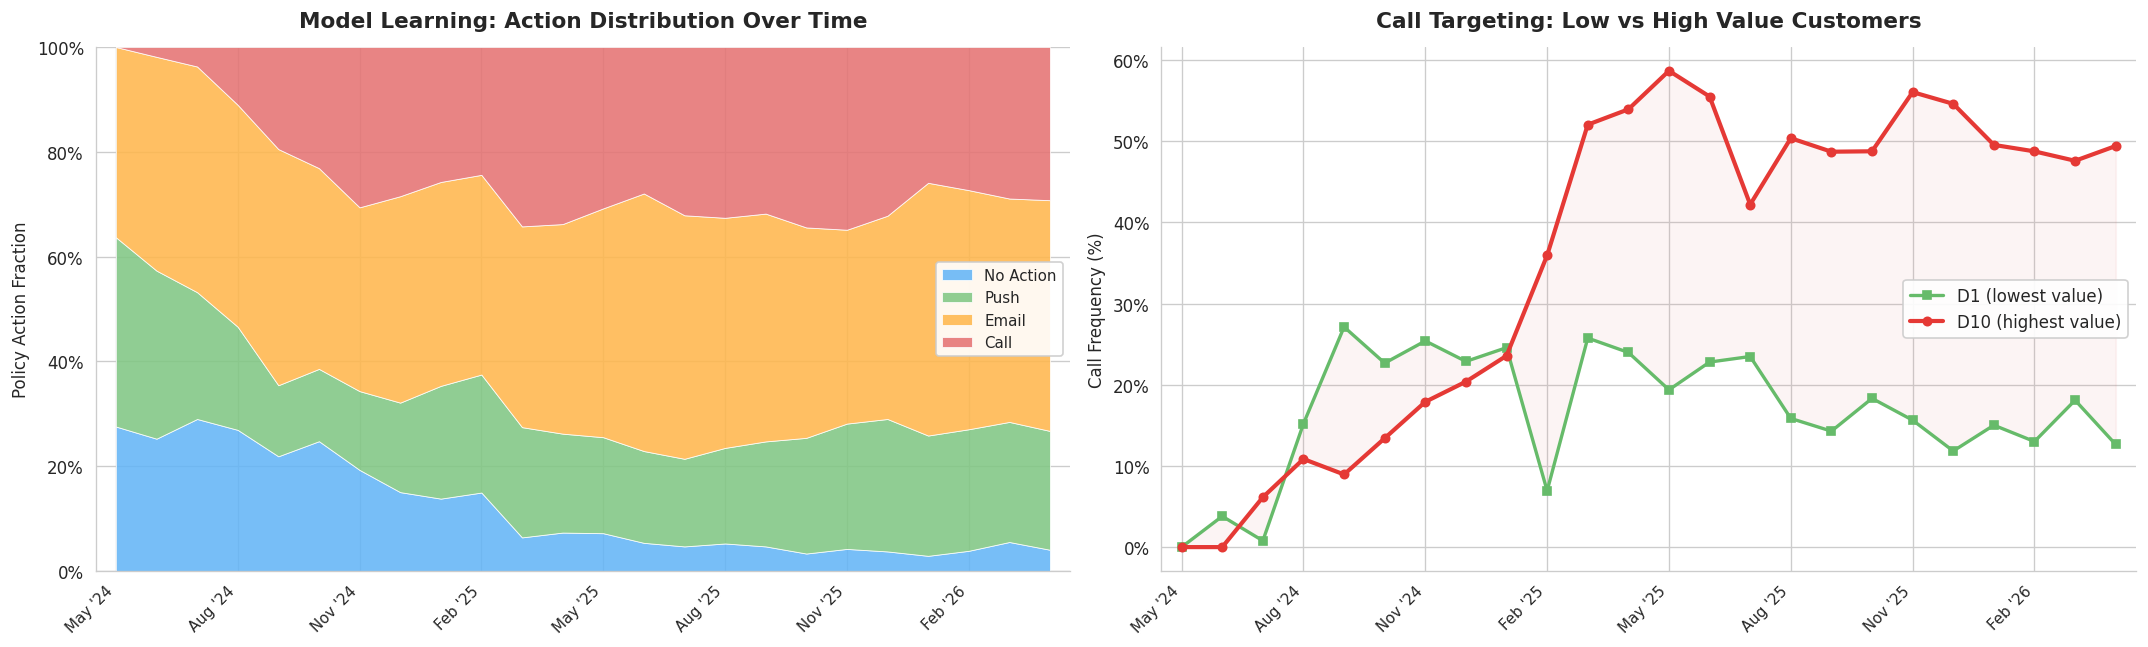

Overall call frequency: months 1-6 = 9.9%, months 19-24 = 29.7%
  D1  (lowest value):  0.0% → 12.6%
  D10 (highest value): 0.0% → 49.4%


In [109]:
action_colors = {"no_action": "#64B5F6", "push_notification": "#81C784",
                 "email": "#FFB74D", "call": "#E57373"}
action_labels = {"no_action": "No Action", "push_notification": "Push",
                 "email": "Email", "call": "Call"}

month_labels = [pd.Timestamp(r.month).strftime("%b '%y") for _, r in mdf.iterrows()]
tick_step = 3

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

# ── Left: Stacked area — policy action mix over time ──
ax = axes[0]
x = np.arange(len(mdf))
bottom = np.zeros(len(mdf))
for a_name in ACTIONS:
    vals = mdf[f"frac_{a_name}"].values
    ax.fill_between(x, bottom, bottom + vals, color=action_colors[a_name],
                    alpha=0.88, label=action_labels[a_name], linewidth=0.5, edgecolor="white")
    bottom += vals

ax.set_xticks(range(0, len(mdf), tick_step))
ax.set_xticklabels([month_labels[i] for i in range(0, len(mdf), tick_step)],
                   rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Policy Action Fraction", fontsize=10)
ax.set_title("Model Learning: Action Distribution Over Time", fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="center right", fontsize=9, framealpha=0.9, edgecolor="#ccc")
ax.set_ylim(0, 1.0)
ax.set_xlim(-0.5, len(mdf) - 0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))

# ── Right: Call frequency D1 vs D10 value ──
ax2 = axes[1]

ax2.fill_between(range(len(mdf)), mdf["call_frac_D1"].values * 100,
                 mdf["call_frac_D10"].values * 100, alpha=0.08, color="#E57373")
ax2.plot(range(len(mdf)), mdf["call_frac_D1"].values * 100, "s-",
         color="#66BB6A", markersize=5, linewidth=2, label="D1 (lowest value)")
ax2.plot(range(len(mdf)), mdf["call_frac_D10"].values * 100, "o-",
         color="#E53935", markersize=5, linewidth=2.5, label="D10 (highest value)")

ax2.set_xticks(range(0, len(mdf), tick_step))
ax2.set_xticklabels([month_labels[i] for i in range(0, len(mdf), tick_step)],
                    rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("Call Frequency (%)", fontsize=10)
ax2.set_title("Call Targeting: Low vs High Value Customers", fontsize=13, fontweight="bold", pad=12)
ax2.legend(fontsize=10, loc="center right", framealpha=0.9, edgecolor="#ccc")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax2.set_xlim(-0.5, len(mdf) - 0.5)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../data/output/bandit_learning_progression.png", dpi=150, bbox_inches="tight")
plt.show()

early_call = mdf[mdf["month_idx"] < 6]["frac_call"].mean()
late_call = mdf[mdf["month_idx"] >= 18]["frac_call"].mean()
print(f"Overall call frequency: months 1-6 = {early_call:.1%}, months 19-24 = {late_call:.1%}")
print(f"  D1  (lowest value):  {mdf['call_frac_D1'].iloc[0]:.1%} → {mdf['call_frac_D1'].iloc[-1]:.1%}")
print(f"  D10 (highest value): {mdf['call_frac_D10'].iloc[0]:.1%} → {mdf['call_frac_D10'].iloc[-1]:.1%}")

### 4.2 Revenue impact and production projection

Expected reward improvement and cumulative revenue saved, projected to a bank with 500,000 accounts.

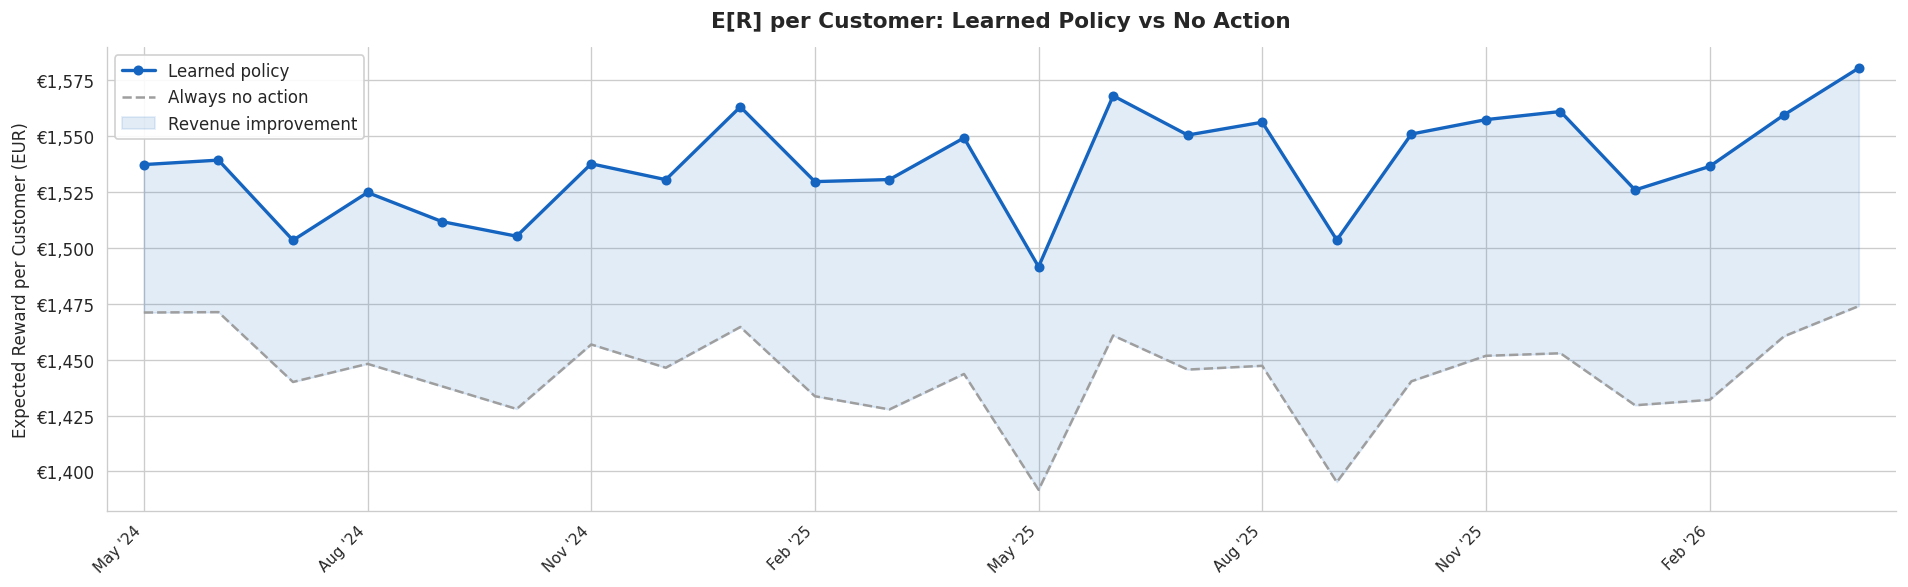

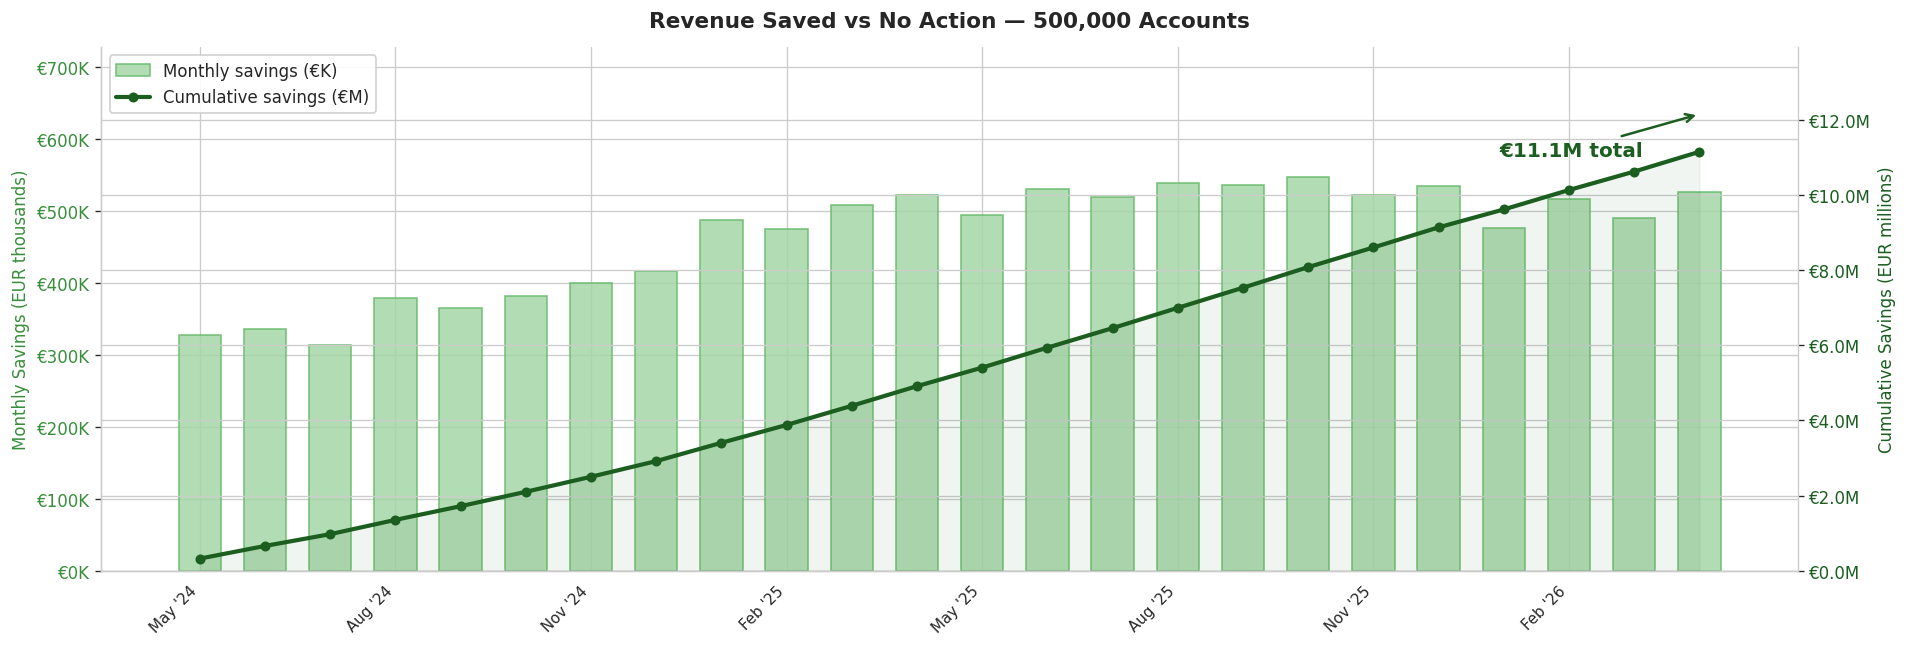

Scaling: simulation → production
  Sim avg value: €1,768/yr  →  Real: €600/yr (×0.339)
  Sim avg churn: 23%         →  Real: 8% (×0.35)
  Combined realism scale: 0.1186

Projection for 500,000 accounts:
  Steady-state annual savings (avg m13-24): €6,231,819
  Cumulative savings over 24 months:        €11,143,878


In [121]:
# ── Realistic production projection ──
sim_avg_value = df["customer_value_score"].mean()
sim_avg_churn = df["churn_risk_score"].mean()

REAL_AVG_REVENUE = 600    # EUR/customer/year (Croatian retail bank estimate)
REAL_CHURN_RATE = 0.08    # ~8% annual churn rate

value_scale = REAL_AVG_REVENUE / sim_avg_value
churn_scale = REAL_CHURN_RATE / sim_avg_churn
realism_scale = value_scale * churn_scale

mdf["projected_annual_savings_500k"] = (
    mdf["improvement_vs_noaction"] * realism_scale * BANK_ACCOUNTS
)
mdf["monthly_savings_500k"] = mdf["projected_annual_savings_500k"] / 12
mdf["cumul_savings_500k"] = mdf["monthly_savings_500k"].cumsum()

month_labels = [pd.Timestamp(r.month).strftime("%b '%y") for _, r in mdf.iterrows()]
tick_step = 3

# ── Chart 1: E[R] per customer — full width ──
fig1, ax1 = plt.subplots(figsize=(16, 5))

ax1.plot(range(len(mdf)), mdf["policy_er"], "o-", color="#1565C0",
         markersize=5, linewidth=2, label="Learned policy", zorder=3)
ax1.plot(range(len(mdf)), mdf["noaction_er"], "--", color="#9E9E9E",
         linewidth=1.5, label="Always no action")
ax1.fill_between(range(len(mdf)), mdf["noaction_er"], mdf["policy_er"],
                 where=mdf["policy_er"] > mdf["noaction_er"],
                 alpha=0.12, color="#1565C0", label="Revenue improvement")

ax1.set_xticks(range(0, len(mdf), tick_step))
ax1.set_xticklabels([month_labels[i] for i in range(0, len(mdf), tick_step)],
                    rotation=45, ha="right", fontsize=9)
ax1.set_ylabel("Expected Reward per Customer (EUR)", fontsize=10)
ax1.set_title("E[R] per Customer: Learned Policy vs No Action", fontsize=13, fontweight="bold", pad=12)
ax1.legend(fontsize=10, framealpha=0.9, edgecolor="#ccc")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax1.spines[["top", "right"]].set_visible(False)
ax1.set_xlim(-0.5, len(mdf) - 0.5)

plt.tight_layout()
plt.savefig("../data/output/bandit_er_per_customer.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Chart 2: Revenue saved — full width, dual axis with clear separation ──
fig2, ax2 = plt.subplots(figsize=(16, 5.5))

monthly_k = mdf["monthly_savings_500k"].values / 1e3
cumul_m = mdf["cumul_savings_500k"].values / 1e6

# Bars: monthly savings
bars = ax2.bar(range(len(mdf)), monthly_k, color="#A5D6A7", edgecolor="#66BB6A",
               alpha=0.85, width=0.65, label="Monthly savings (€K)", zorder=2)

ax2.set_xticks(range(0, len(mdf), tick_step))
ax2.set_xticklabels([month_labels[i] for i in range(0, len(mdf), tick_step)],
                    rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("Monthly Savings (EUR thousands)", fontsize=10, color="#388E3C")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}K"))
ax2.tick_params(axis="y", labelcolor="#388E3C")
ax2.spines[["top", "right"]].set_visible(False)

# Bars fill ~75% of chart height
max_monthly = max(monthly_k) if max(monthly_k) > 0 else 1
ax2.set_ylim(0, max_monthly * 1.33)

# Cumulative line on secondary axis
ax2_twin = ax2.twinx()
ax2_twin.plot(range(len(mdf)), cumul_m, "o-", color="#1B5E20",
              markersize=5, linewidth=2.5, label="Cumulative savings (€M)", zorder=3)
ax2_twin.fill_between(range(len(mdf)), 0, cumul_m, alpha=0.06, color="#1B5E20")
ax2_twin.set_ylabel("Cumulative Savings (EUR millions)", fontsize=10, color="#1B5E20")
ax2_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.1f}M"))
ax2_twin.tick_params(axis="y", labelcolor="#1B5E20")
ax2_twin.spines["top"].set_visible(False)
ax2_twin.set_ylim(0, max(cumul_m) * 1.25)

ax2.set_title(f"Revenue Saved vs No Action — {BANK_ACCOUNTS:,} Accounts", fontsize=13, fontweight="bold", pad=12)

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10,
           framealpha=0.9, edgecolor="#ccc")

# Annotate final cumulative total
final_cumul = mdf["cumul_savings_500k"].iloc[-1]
ax2_twin.annotate(f"€{final_cumul/1e6:,.1f}M total", xy=(len(mdf)-1, 1+final_cumul/1e6),
                  xytext=(-120, -25), textcoords="offset points",
                  fontsize=12, fontweight="bold", color="#1B5E20",
                  arrowprops=dict(arrowstyle="->", color="#1B5E20", lw=1.5))

plt.tight_layout()
plt.savefig("../data/output/bandit_revenue_saved.png", dpi=150, bbox_inches="tight")
plt.show()

# Print projection summary
steady_annual = mdf[mdf["month_idx"] >= 12]["projected_annual_savings_500k"].mean()

print(f"Scaling: simulation → production")
print(f"  Sim avg value: €{sim_avg_value:,.0f}/yr  →  Real: €{REAL_AVG_REVENUE}/yr (×{value_scale:.3f})")
print(f"  Sim avg churn: {sim_avg_churn:.0%}         →  Real: {REAL_CHURN_RATE:.0%} (×{churn_scale:.2f})")
print(f"  Combined realism scale: {realism_scale:.4f}")
print(f"\nProjection for {BANK_ACCOUNTS:,} accounts:")
print(f"  Steady-state annual savings (avg m13-24): €{steady_annual:,.0f}")
print(f"  Cumulative savings over 24 months:        €{final_cumul:,.0f}")

### 4.3 Parameter dynamics (‖θ_a‖ over time)

Per Section 7: "the estimated call-model coefficients θ_{a3} should stabilize as evidence accumulates".

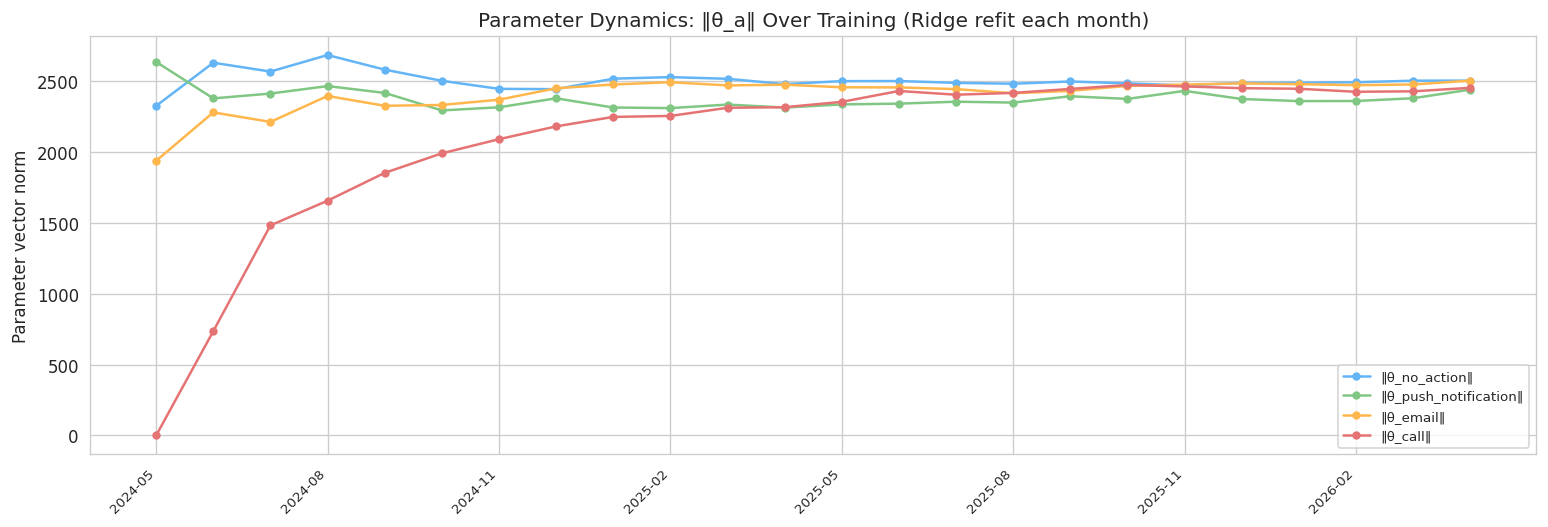

In [111]:
fig, ax = plt.subplots(figsize=(13, 4.5))

month_labels = [pd.Timestamp(r.month).strftime("%Y-%m") for _, r in mdf.iterrows()]

for a_name in ACTIONS:
    ax.plot(range(len(mdf)), mdf[f"theta_norm_{a_name}"],
            "o-", color=action_colors[a_name], markersize=4, linewidth=1.5,
            label=f"‖θ_{a_name}‖")

tick_step = 3
ax.set_xticks(range(0, len(mdf), tick_step))
ax.set_xticklabels([month_labels[i] for i in range(0, len(mdf), tick_step)],
                   rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Parameter vector norm")
ax.set_title("Parameter Dynamics: ‖θ_a‖ Over Training (Ridge refit each month)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/output/bandit_theta_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Holdout Evaluation with Ground-Truth Rewards

We use the last 6 months as holdout and evaluate using the **true expected reward** $E[R(a)] = (1 - p(a)) \cdot v - c(a)$ for each action. This gives exact, unbiased policy comparison — no need for matched or IPS estimation.

In [112]:
# Use last 6 months as holdout
holdout_months = months[-6:]
holdout_mask = df["reference_month"].isin(holdout_months)
df_holdout = df[holdout_mask].reset_index(drop=True)
X_holdout = X_all[holdout_mask.values]
ER_holdout = ER_matrix[holdout_mask.values]  # ground-truth expected rewards

print(f"Holdout: {len(df_holdout):,} rows, months: {[pd.Timestamp(m).strftime('%Y-%m') for m in holdout_months]}")

# ── Learned policy actions on holdout ──
learned_actions = np.array([bandit.select_action(X_holdout[i], explore=False)
                            for i in range(len(X_holdout))])
learned_action_names = [ACTIONS[a] for a in learned_actions]

# ── Ground-truth expected reward of learned policy ──
learned_er = np.array([ER_holdout[i, learned_actions[i]] for i in range(len(df_holdout))])

print(f"\nLearned policy:")
print(f"  Avg E[R]: €{learned_er.mean():,.0f}")
for a_name in ACTIONS:
    frac = (np.array(learned_action_names) == a_name).mean()
    print(f"  {a_name}: {frac:.1%}")

Holdout: 15,000 rows, months: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']

Learned policy:
  Avg E[R]: €1,554
  no_action: 4.6%
  push_notification: 23.1%
  email: 42.9%
  call: 29.4%


In [113]:
# ── Net Revenue Saved per Customer (vs Do-Nothing baseline) ──
# Positive = strategy earns more than doing nothing (after action costs)
# Negative = strategy wastes money compared to doing nothing
# Note: E[R] already includes action costs (reward = (1−Y)·v − cost)

noaction_baseline = ER_holdout[:, 0].mean()  # E[R] of doing nothing
v_holdout = df_holdout["customer_value_score"].values

results = {}

# Baselines vs no_action
results["Always no_action"] = 0.0  # reference
results["Always push"] = (ER_holdout[:, 1] - ER_holdout[:, 0]).mean()
results["Always email"] = (ER_holdout[:, 2] - ER_holdout[:, 0]).mean()
results["Always call"] = (ER_holdout[:, 3] - ER_holdout[:, 0]).mean()

# Uniform random
np.random.seed(123)
uniform_actions = np.random.randint(0, N_ACTIONS, size=len(df_holdout))
uniform_er = np.array([ER_holdout[i, uniform_actions[i]] for i in range(len(df_holdout))])
results["Uniform random"] = (uniform_er - ER_holdout[:, 0]).mean()

# Learned policy
results["Learned policy"] = (learned_er - ER_holdout[:, 0]).mean()

print("=" * 68)
print("  HOLDOUT: NET REVENUE SAVED PER CUSTOMER (EUR)")
print("  = E[R](strategy) − E[R](no_action)")
print("  Positive = earns more than doing nothing (after costs)")
print("=" * 68)
for name, impact in sorted(results.items(), key=lambda x: -x[1]):
    marker = " ◀ LEARNED" if name == "Learned policy" else ""
    sign = "+" if impact >= 0 else ""
    print(f"  {name:<22s}  {sign}€{impact:>7,.0f}{marker}")
print("=" * 68)

improvement = results["Learned policy"]
print(f"\n  Learned policy saves +€{improvement:,.0f}/customer vs doing nothing")
print(f"  Learned policy saves +€{improvement - results['Always call']:,.0f}/customer vs always calling")
print(f"  Learned policy saves +€{improvement - results['Always email']:,.0f}/customer vs always emailing")

n_holdout = len(df_holdout)
projected_annual_holdout = improvement * realism_scale * BANK_ACCOUNTS
print(f"\n  Production projection ({BANK_ACCOUNTS:,} accounts):")
print(f"    Annual revenue saved: €{projected_annual_holdout:,.0f}")
print(f"    2-year revenue saved: €{projected_annual_holdout * 2:,.0f}")

  HOLDOUT: NET REVENUE SAVED PER CUSTOMER (EUR)
  = E[R](strategy) − E[R](no_action)
  Positive = earns more than doing nothing (after costs)
  Learned policy          +€    104 ◀ LEARNED
  Always email            +€     77
  Always call             +€     65
  Uniform random          +€     40
  Always push             +€     15
  Always no_action        +€      0

  Learned policy saves +€104/customer vs doing nothing
  Learned policy saves +€39/customer vs always calling
  Learned policy saves +€27/customer vs always emailing

  Production projection (500,000 accounts):
    Annual revenue saved: €6,182,718
    2-year revenue saved: €12,365,436


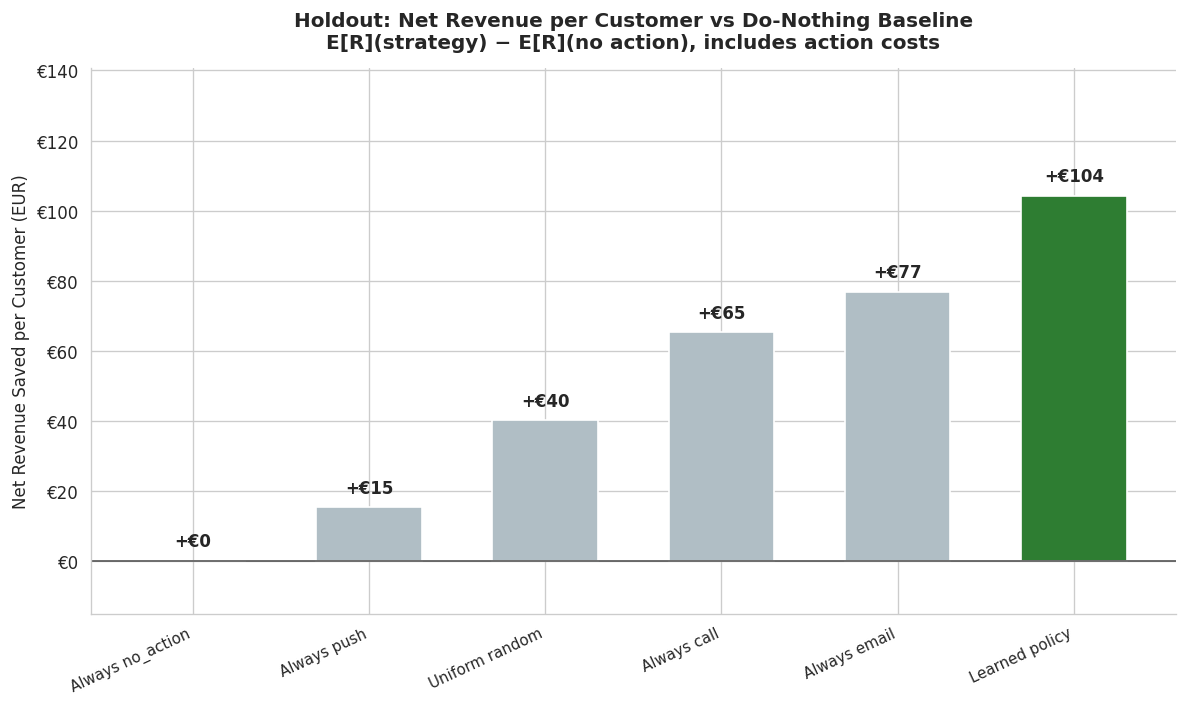

In [114]:
# ── Visual: Net Revenue Saved per Customer (vs Do-Nothing) — vertical bars ──
fig, ax = plt.subplots(figsize=(10, 6))

sorted_results = sorted(results.items(), key=lambda x: x[1])
names = [r[0] for r in sorted_results]
vals = [r[1] for r in sorted_results]

colors = ['#2E7D32' if n == "Learned policy" else
          '#EF5350' if v < 0 else
          '#B0BEC5' for n, v in zip(names, vals)]

bars = ax.bar(range(len(names)), vals, color=colors, edgecolor="white", width=0.6)

# Zero line
ax.axhline(0, color="#555", linewidth=1, linestyle="-", zorder=1)

# Value labels on top of bars
for bar, val in zip(bars, vals):
    sign = "+" if val >= 0 else ""
    y_off = 3 if val >= 0 else -3
    va = "bottom" if val >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width()/2, val + y_off,
            f"{sign}€{val:,.0f}", ha="center", va=va, fontsize=10, fontweight="bold")

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=9, rotation=25, ha="right")
ax.set_ylabel("Net Revenue Saved per Customer (EUR)", fontsize=10)
ax.set_title("Holdout: Net Revenue per Customer vs Do-Nothing Baseline\n"
             "E[R](strategy) − E[R](no action), includes action costs",
             fontsize=12, fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)

# Give headroom for labels
y_min = min(vals) * 1.3 if min(vals) < 0 else -15
y_max = max(vals) * 1.35
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig("../data/output/bandit_policy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.1 Learned action mix by customer value decile

Per Section 7: "call selection probability increases with expected value/uplift, not uniformly for all customers"

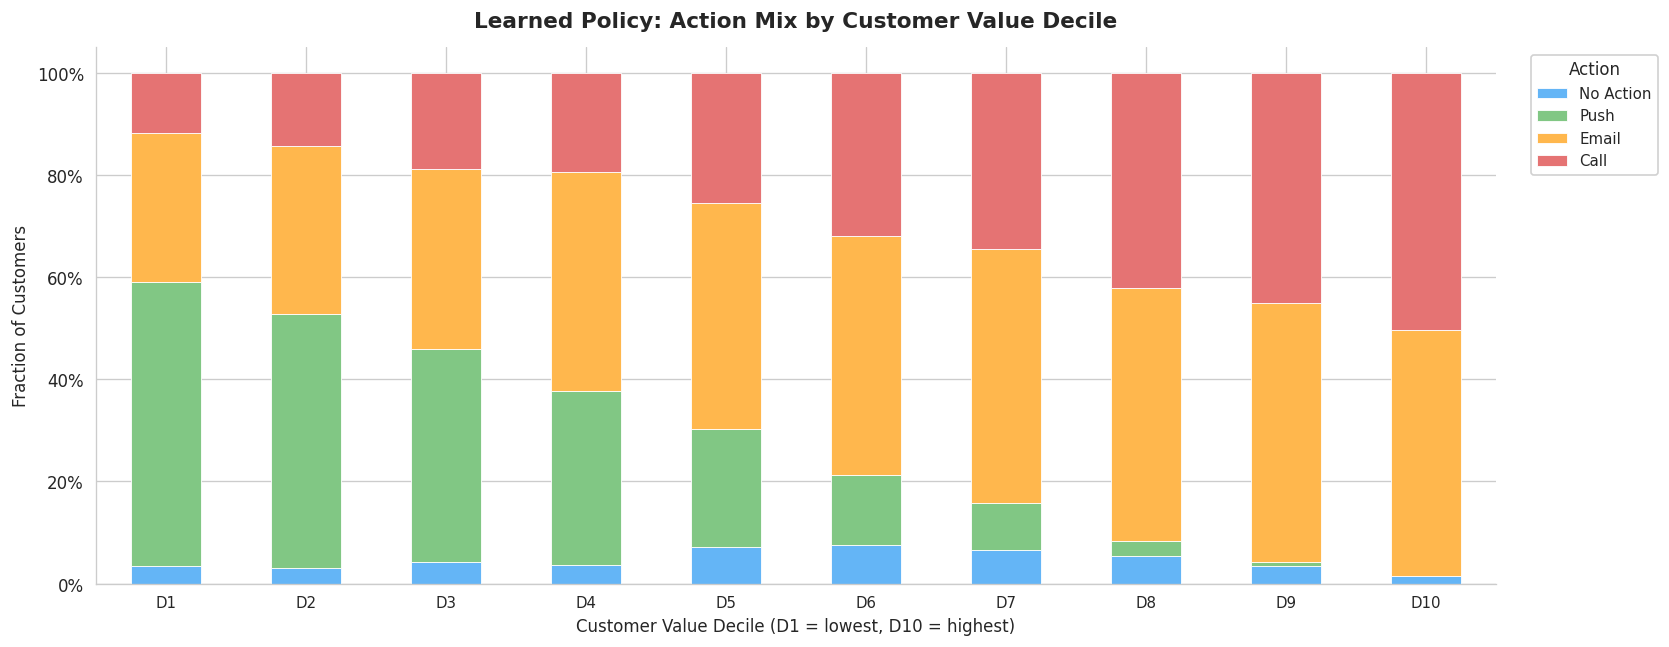


Action fractions by value decile:
learned_action  no_action  push_notification  email   call
value_decile                                              
D1                  0.034              0.557  0.292  0.117
D2                  0.031              0.496  0.328  0.145
D3                  0.042              0.418  0.352  0.188
D4                  0.036              0.340  0.429  0.195
D5                  0.071              0.232  0.441  0.255
D6                  0.076              0.137  0.468  0.319
D7                  0.066              0.091  0.497  0.346
D8                  0.053              0.031  0.494  0.422
D9                  0.034              0.008  0.507  0.451
D10                 0.015              0.000  0.481  0.504

Call fraction D1=0.117, D10=0.504 → ✓ Calls increase with value


In [115]:
# Build evaluation DataFrame
df_eval = df_holdout.copy()
df_eval["learned_action"] = learned_action_names
df_eval["learned_er"] = learned_er

df_eval["value_decile"] = pd.qcut(df_eval["customer_value_score"], 10,
                                   labels=[f"D{i}" for i in range(1, 11)])

action_by_value = pd.crosstab(df_eval["value_decile"], df_eval["learned_action"],
                               normalize="index")[ACTIONS]

fig, ax = plt.subplots(figsize=(14, 5.5))
action_by_value.plot(kind="bar", stacked=True, ax=ax,
                      color=[action_colors[a] for a in ACTIONS], edgecolor="white", linewidth=0.5)
ax.set_ylabel("Fraction of Customers", fontsize=10)
ax.set_xlabel("Customer Value Decile (D1 = lowest, D10 = highest)", fontsize=10)
ax.set_title("Learned Policy: Action Mix by Customer Value Decile", fontsize=13, fontweight="bold", pad=12)
ax.legend(title="Action", labels=[action_labels[a] for a in ACTIONS],
          bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, title_fontsize=10,
          framealpha=0.9, edgecolor="#ccc")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../data/output/bandit_actions_by_value.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAction fractions by value decile:")
print(action_by_value.round(3).to_string())
call_d1 = action_by_value.loc["D1", "call"]
call_d10 = action_by_value.loc["D10", "call"]
print(f"\nCall fraction D1={call_d1:.3f}, D10={call_d10:.3f} → {'✓ Calls increase with value' if call_d10 > call_d1 else '✗ Issue'}")

### 5.2 Learned action mix by churn risk decile

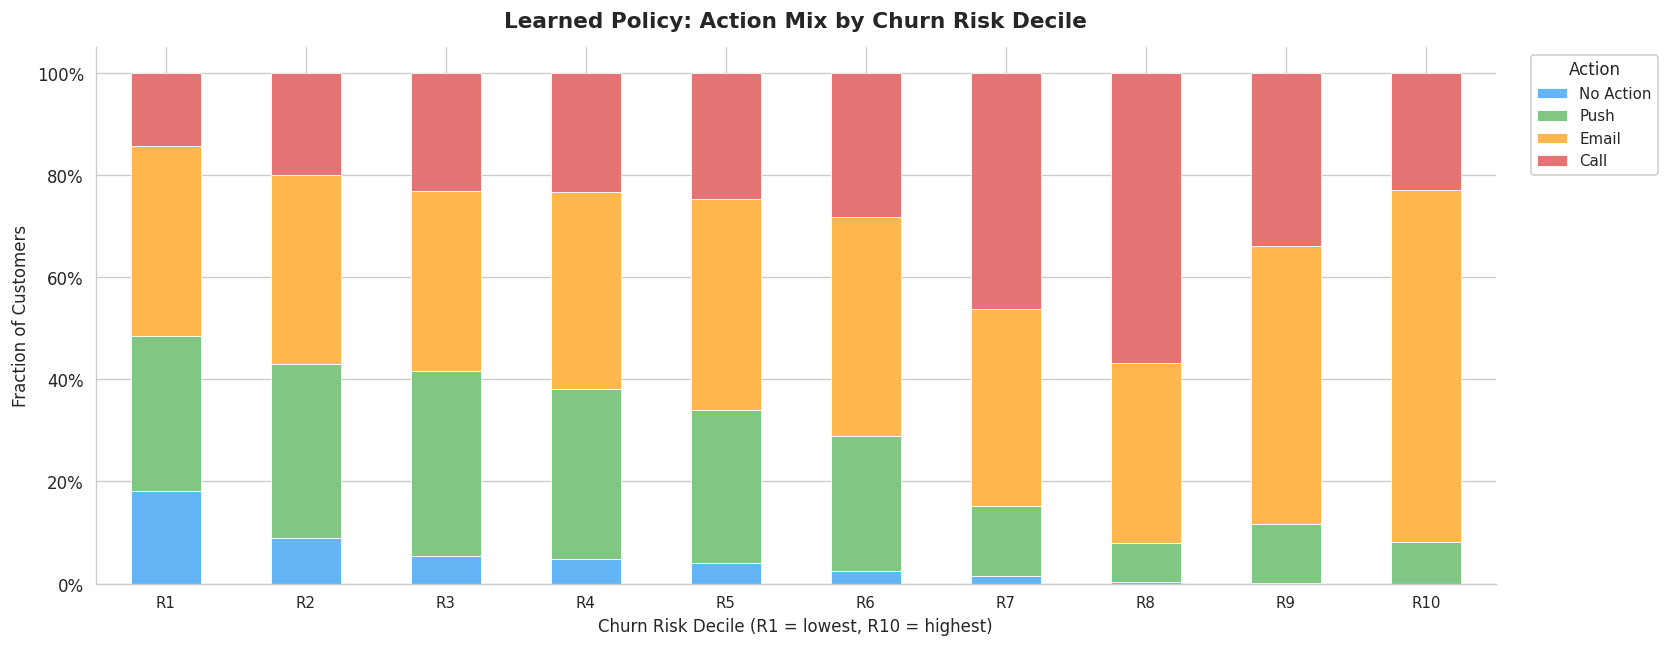


Action fractions by risk decile:
learned_action  no_action  push_notification  email   call
risk_decile                                               
R1                  0.182              0.303  0.371  0.144
R2                  0.090              0.340  0.370  0.200
R3                  0.055              0.361  0.353  0.231
R4                  0.049              0.332  0.385  0.235
R5                  0.040              0.301  0.411  0.248
R6                  0.025              0.263  0.429  0.283
R7                  0.015              0.137  0.385  0.463
R8                  0.003              0.077  0.353  0.567
R9                  0.001              0.115  0.544  0.340
R10                 0.000              0.081  0.689  0.231


In [116]:
df_eval["risk_decile"] = pd.qcut(df_eval["churn_risk_score"], 10,
                                 labels=[f"R{i}" for i in range(1, 11)], duplicates="drop")

action_by_risk = pd.crosstab(df_eval["risk_decile"], df_eval["learned_action"],
                              normalize="index")[ACTIONS]

fig, ax = plt.subplots(figsize=(14, 5.5))
action_by_risk.plot(kind="bar", stacked=True, ax=ax,
                     color=[action_colors[a] for a in ACTIONS], edgecolor="white", linewidth=0.5)
ax.set_ylabel("Fraction of Customers", fontsize=10)
ax.set_xlabel("Churn Risk Decile (R1 = lowest, R10 = highest)", fontsize=10)
ax.set_title("Learned Policy: Action Mix by Churn Risk Decile", fontsize=13, fontweight="bold", pad=12)
ax.legend(title="Action", labels=[action_labels[a] for a in ACTIONS],
          bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, title_fontsize=10,
          framealpha=0.9, edgecolor="#ccc")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../data/output/bandit_actions_by_risk.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAction fractions by risk decile:")
print(action_by_risk.round(3).to_string())

### 5.3 Call probability heatmap: Risk × Value

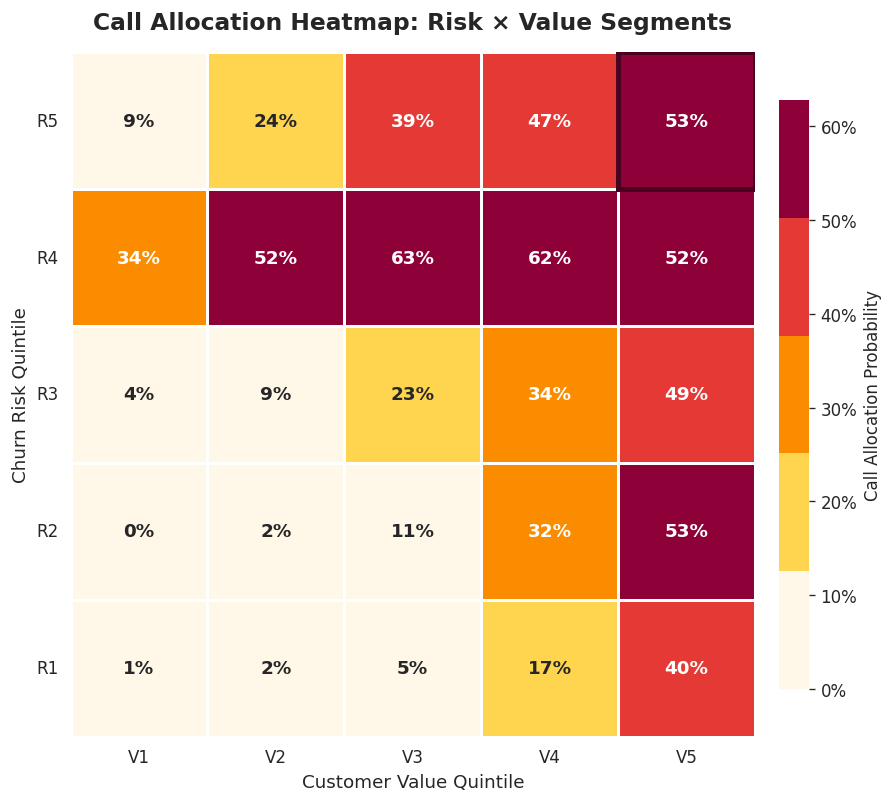

In [126]:
# ── Deterministic call allocation heatmap: risk × value quintiles ──
value_labels = ["V1", "V2", "V3", "V4", "V5"]
risk_labels = ["R1", "R2", "R3", "R4", "R5"]

df_eval["value_q5"] = pd.qcut(
    df_eval["customer_value_score"].rank(method="first"),
    5,
    labels=value_labels,
)
df_eval["risk_q5"] = pd.qcut(
    df_eval["churn_risk_score"].rank(method="first"),
    5,
    labels=risk_labels,
)

df_eval["is_call"] = (df_eval["learned_action"] == "call").astype(float)

call_heatmap = (
    df_eval.pivot_table("is_call", index="risk_q5", columns="value_q5", aggfunc="mean")
    .reindex(index=risk_labels[::-1], columns=value_labels)
)

annot_labels = call_heatmap.copy().astype(object)
for r in call_heatmap.index:
    for c in call_heatmap.columns:
        annot_labels.loc[r, c] = f"{call_heatmap.loc[r, c]:.0%}"

fig, ax = plt.subplots(figsize=(10.5, 6.8))
cmap = sns.color_palette(["#FFF8E8", "#FFD54F", "#FB8C00", "#E53935", "#8E0038"], as_cmap=True)

sns.heatmap(
    call_heatmap,
    ax=ax,
    cmap=cmap,
    vmin=0,
    vmax=max(0.55, float(call_heatmap.max().max())),
    annot=annot_labels,
    fmt="",
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar_kws={"label": "Call Allocation Probability", "shrink": 0.86, "pad": 0.02},
    annot_kws={"fontsize": 11, "fontweight": "bold"},
)

ax.set_title("Call Allocation Heatmap: Risk × Value Segments", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Customer Value Quintile", fontsize=11)
ax.set_ylabel("Churn Risk Quintile", fontsize=11)
ax.set_xticklabels(value_labels, rotation=0, fontsize=10)
ax.set_yticklabels(["R5", "R4", "R3", "R2", "R1"], rotation=0, fontsize=10)

# Clean visual emphasis for the high-risk / high-value corner.
ax.add_patch(plt.Rectangle((4, 0), 1, 1, fill=False, edgecolor="#4A001F", linewidth=3))

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("../data/output/bandit_call_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Deep Dive: Two Customer Archetypes — Temporal Learning

We define two contrasting customer profiles and examine **how the model gradually discovers the right strategy** using bandit snapshots saved during training:
- **Low-value**: bottom 20% value score, 1 product, below-median balance & transactions
- **High-value**: top 20% value score, 3+ products, above-median balance & transactions

We focus on:
1. **Low-value by tenure**: how the action mix evolves across training months for each tenure group
2. **High-value by digital engagement**: how the model learns to differentiate by digital activity

In [118]:
# ── Define two customer archetypes ──
median_bal = df_holdout["avg_balance"].median()
median_txn = df_holdout["avg_txn_per_month"].median()
value_20 = df_holdout["customer_value_score"].quantile(0.20)
value_80 = df_holdout["customer_value_score"].quantile(0.80)

low_mask = (
    (df_eval["customer_value_score"] <= value_20) &
    (df_eval["n_products"] <= 1) &
    (df_eval["avg_balance"] < median_bal) &
    (df_eval["avg_txn_per_month"] < median_txn)
)
high_mask = (
    (df_eval["customer_value_score"] >= value_80) &
    (df_eval["n_products"] >= 3) &
    (df_eval["avg_balance"] >= median_bal) &
    (df_eval["avg_txn_per_month"] >= median_txn)
)

df_low = df_eval[low_mask].copy()
df_high = df_eval[high_mask].copy()

# Action fracs & E[R] per segment
low_fracs = df_low["learned_action"].value_counts(normalize=True).reindex(ACTIONS, fill_value=0)
high_fracs = df_high["learned_action"].value_counts(normalize=True).reindex(ACTIONS, fill_value=0)
low_er = df_low["learned_er"].mean()
high_er = df_high["learned_er"].mean()

# Segment summary table
print(f"{'Metric':<28s}  {'Low-Value':>12s}  {'High-Value':>12s}")
print("─" * 56)
print(f"{'n customers':<28s}  {len(df_low):>12,d}  {len(df_high):>12,d}")
print(f"{'% of holdout':<28s}  {len(df_low)/len(df_eval):>11.1%}  {len(df_high)/len(df_eval):>11.1%}")
print(f"{'Avg value score':<28s}  €{df_low['customer_value_score'].mean():>10,.0f}  €{df_high['customer_value_score'].mean():>10,.0f}")
print(f"{'Avg churn risk':<28s}  {df_low['churn_risk_score'].mean():>11.1%}  {df_high['churn_risk_score'].mean():>11.1%}")
print(f"{'Avg balance':<28s}  €{df_low['avg_balance'].mean():>10,.0f}  €{df_high['avg_balance'].mean():>10,.0f}")
print(f"{'Avg products':<28s}  {df_low['n_products'].mean():>12.1f}  {df_high['n_products'].mean():>12.1f}")
print(f"{'Avg tenure (years)':<28s}  {df_low['tenure_years'].mean():>12.1f}  {df_high['tenure_years'].mean():>12.1f}")
print(f"{'E[R] learned policy':<28s}  €{low_er:>10,.0f}  €{high_er:>10,.0f}")
print("─" * 56)
for a in ACTIONS:
    print(f"  {action_labels[a]+' freq':<26s}  {low_fracs[a]:>11.1%}  {high_fracs[a]:>11.1%}")

Metric                           Low-Value    High-Value
────────────────────────────────────────────────────────
n customers                          1,140         1,479
% of holdout                         7.6%         9.9%
Avg value score               €       174  €     5,186
Avg churn risk                      38.6%         9.7%
Avg balance                   €       -18  €     9,182
Avg products                           1.0           5.9
Avg tenure (years)                    14.6          22.4
E[R] learned policy           €       107  €     4,923
────────────────────────────────────────────────────────
  No Action freq                     2.2%         1.4%
  Push freq                         36.8%         0.7%
  Email freq                        41.8%        45.6%
  Call freq                         19.2%        52.3%


Computing temporal action evolution across 9 snapshots...
Done.



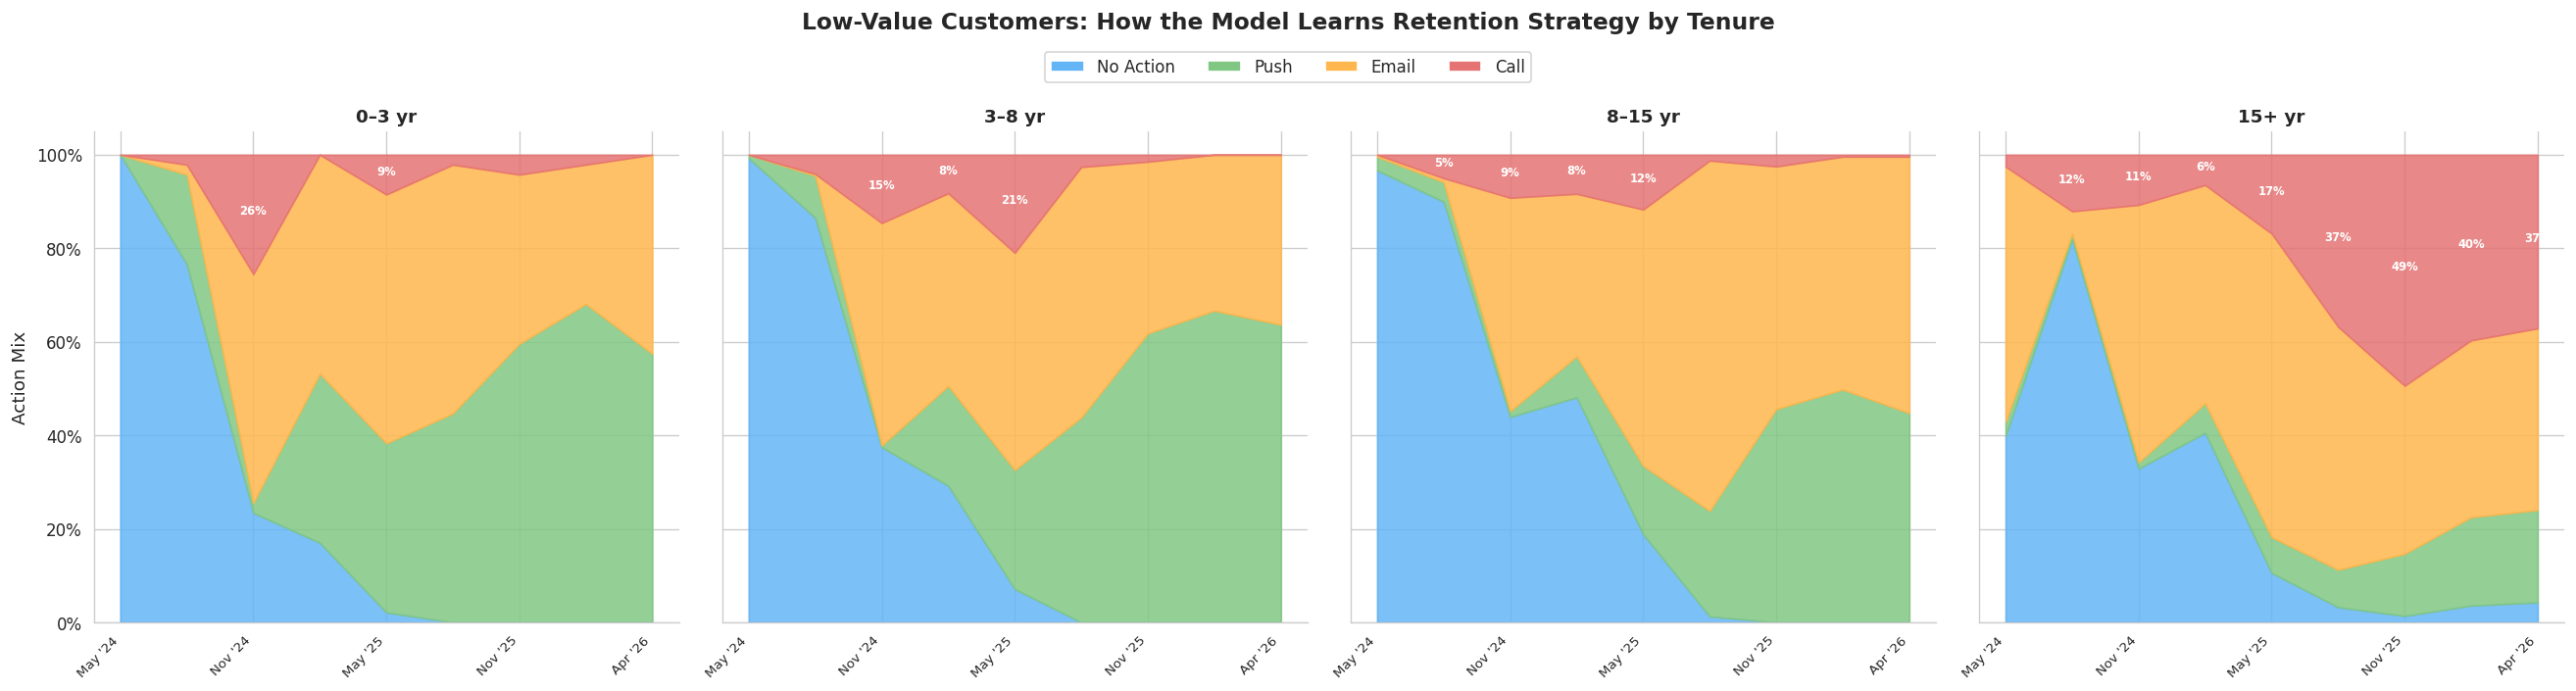

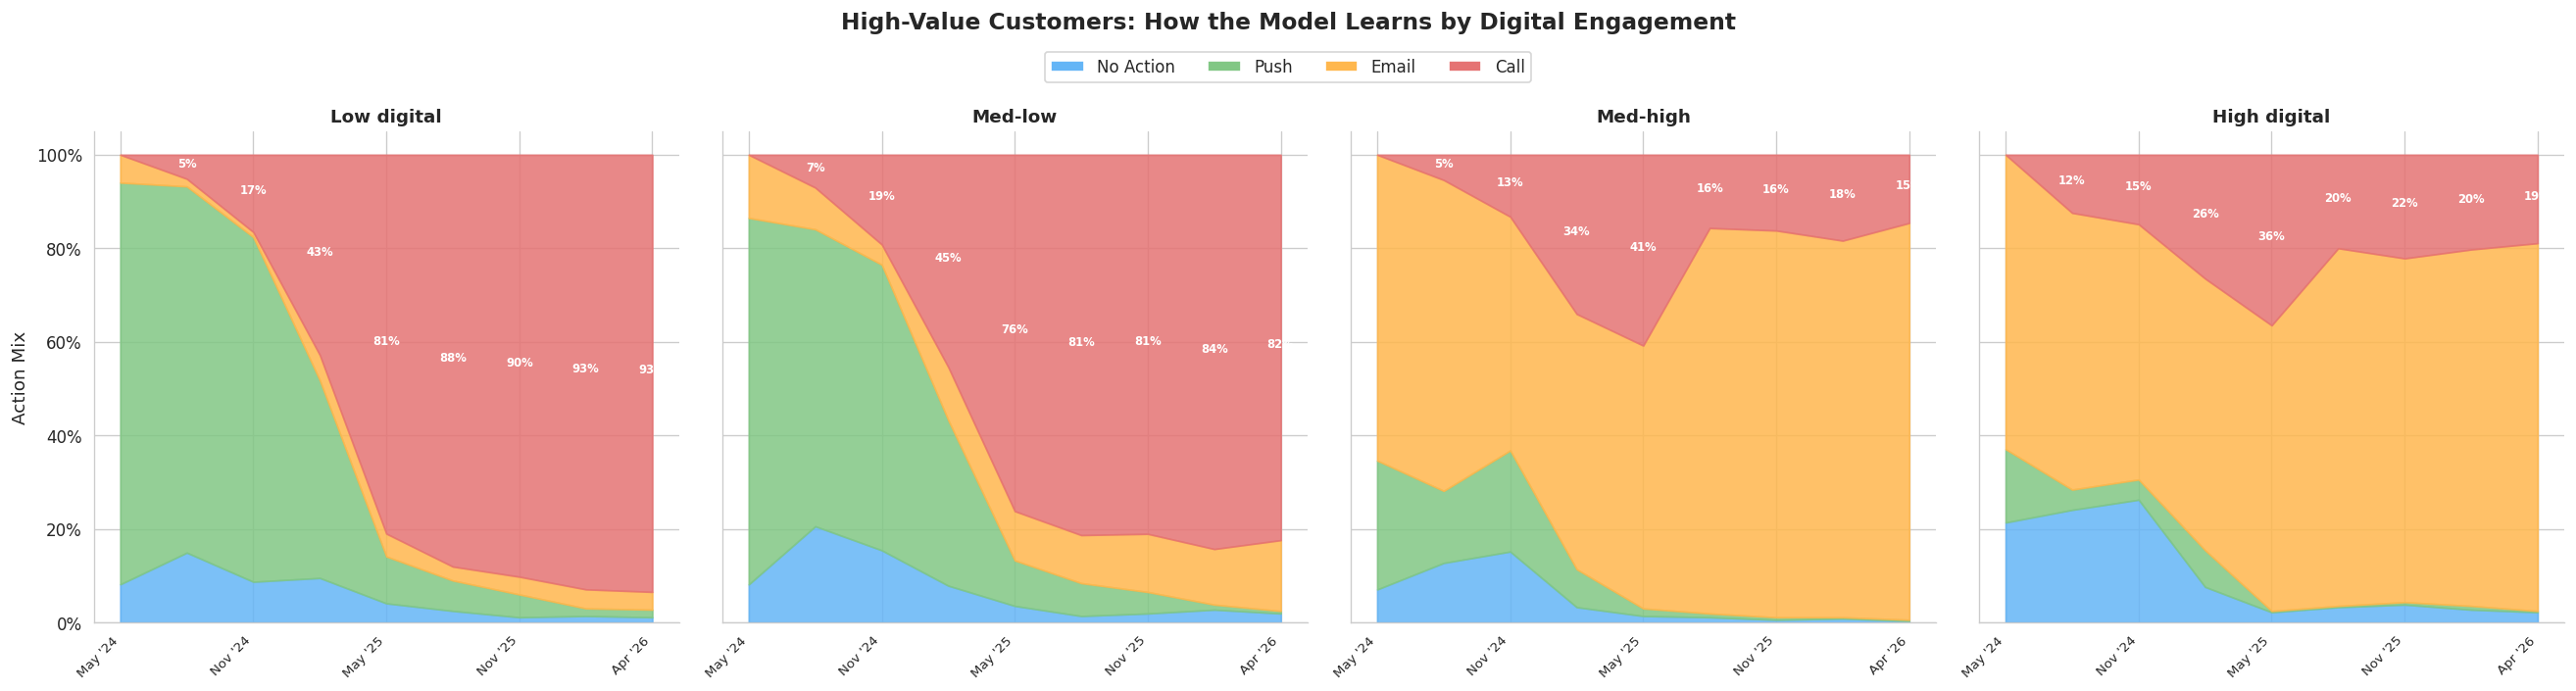

Temporal learning summary (9 snapshots):
  Low-value by tenure (call %):
        0–3 yr:    0% →    0%
        3–8 yr:    0% →    0%
       8–15 yr:    0% →    0%
        15+ yr:    3% →   37%
  High-value by digital engagement (call %):
     Low digital:    0% →   93%
         Med-low:    0% →   82%
        Med-high:    0% →   15%
    High digital:    0% →   19%


In [119]:
# ══════════════════════════════════════════════════════════════════════
#  TEMPORAL LEARNING: How the model discovers the right strategy
#  Using bandit snapshots saved during training
# ══════════════════════════════════════════════════════════════════════

def safe_qcut(series, q, labels):
    """qcut with fallback to fewer bins if duplicates cause issues."""
    try:
        return pd.qcut(series, q, labels=labels, duplicates="drop")
    except ValueError:
        ranks = series.rank(method="first")
        n = len(ranks)
        bins = [labels[min(int(r * q / (n + 1)), q - 1)] for r in ranks]
        return pd.Categorical(bins, categories=labels, ordered=True)

# Bin features for both segments
tenure_bins = ["0–3 yr", "3–8 yr", "8–15 yr", "15+ yr"]
digital_bins = ["Low digital", "Med-low", "Med-high", "High digital"]

for seg_df in [df_low, df_high]:
    seg_df["tenure_bin"] = pd.cut(seg_df["tenure_years"],
                                   bins=[0, 3, 8, 15, 50], labels=tenure_bins)
    seg_df["digital_bin"] = safe_qcut(seg_df["digital_txn_ratio"], 4, digital_bins)

# Map holdout df indices to X_holdout row positions
low_positions = {idx: pos for pos, idx in enumerate(df_holdout.index) if idx in df_low.index}
high_positions = {idx: pos for pos, idx in enumerate(df_holdout.index) if idx in df_high.index}

snapshot_months_sorted = sorted(stage_bandits.keys())
snap_labels = [pd.Timestamp(months[m]).strftime("%b '%y") for m in snapshot_months_sorted]

def get_fracs_over_time(df_seg, positions_map, bin_col, bins):
    """For each snapshot, predict actions and compute fracs per bin per action."""
    result = {b: {a: [] for a in ACTIONS} for b in bins}
    for sm in snapshot_months_sorted:
        sb = stage_bandits[sm]
        seg_actions = {}
        for idx in df_seg.index:
            if idx in positions_map:
                pos = positions_map[idx]
                seg_actions[idx] = ACTIONS[int(np.argmax(sb.predict_rewards(X_holdout[pos])))]
        for b in bins:
            mask = df_seg[bin_col] == b
            bin_indices = df_seg[mask].index
            bin_acts = [seg_actions[i] for i in bin_indices if i in seg_actions]
            n = max(len(bin_acts), 1)
            for a in ACTIONS:
                result[b][a].append(sum(1 for x in bin_acts if x == a) / n)
    return result

print(f"Computing temporal action evolution across {len(snapshot_months_sorted)} snapshots...")
low_tenure_data = get_fracs_over_time(df_low, low_positions, "tenure_bin", tenure_bins)
high_digital_data = get_fracs_over_time(df_high, high_positions, "digital_bin", digital_bins)
print("Done.\n")

# ══════════════════════════════════════════════════════════════════════
#  CHART 1: Low-Value Customers by Tenure — Stacked area evolution
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharey=True)
fig.suptitle("Low-Value Customers: How the Model Learns Retention Strategy by Tenure",
             fontsize=14, fontweight="bold", y=1.06)

x = np.arange(len(snapshot_months_sorted))

for ax_idx, tbin in enumerate(tenure_bins):
    ax = axes[ax_idx]
    bottom = np.zeros(len(x))
    for a in ACTIONS:
        vals = np.array(low_tenure_data[tbin][a])
        ax.fill_between(x, bottom, bottom + vals, alpha=0.85,
                        color=action_colors[a],
                        label=action_labels[a] if ax_idx == 0 else "")
        # Annotate call % on top of call area
        if a == "call":
            for xi, v, b_val in zip(x, vals, bottom):
                if v > 0.05:
                    ax.text(xi, b_val + v / 2, f"{v:.0%}", ha="center", fontsize=7,
                            color="white", fontweight="bold")
        bottom += vals

    ax.set_title(tbin, fontsize=11, fontweight="bold")
    ax.set_xticks(x[::2])
    ax.set_xticklabels([snap_labels[i] for i in range(0, len(snap_labels), 2)],
                       rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Action Mix", fontsize=11)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=action_colors[a]) for a in ACTIONS]
fig.legend(handles, [action_labels[a] for a in ACTIONS],
           loc="upper center", ncol=4, fontsize=10, bbox_to_anchor=(0.5, 1.01))
plt.tight_layout()
plt.savefig("../data/output/bandit_learning_low_tenure.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════
#  CHART 2: High-Value Customers by Digital — Stacked area evolution
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharey=True)
fig.suptitle("High-Value Customers: How the Model Learns by Digital Engagement",
             fontsize=14, fontweight="bold", y=1.06)

for ax_idx, dbin in enumerate(digital_bins):
    ax = axes[ax_idx]
    bottom = np.zeros(len(x))
    for a in ACTIONS:
        vals = np.array(high_digital_data[dbin][a])
        ax.fill_between(x, bottom, bottom + vals, alpha=0.85,
                        color=action_colors[a],
                        label=action_labels[a] if ax_idx == 0 else "")
        if a == "call":
            for xi, v, b_val in zip(x, vals, bottom):
                if v > 0.05:
                    ax.text(xi, b_val + v / 2, f"{v:.0%}", ha="center", fontsize=7,
                            color="white", fontweight="bold")
        bottom += vals

    ax.set_title(dbin, fontsize=11, fontweight="bold")
    ax.set_xticks(x[::2])
    ax.set_xticklabels([snap_labels[i] for i in range(0, len(snap_labels), 2)],
                       rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Action Mix", fontsize=11)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=action_colors[a]) for a in ACTIONS]
fig.legend(handles, [action_labels[a] for a in ACTIONS],
           loc="upper center", ncol=4, fontsize=10, bbox_to_anchor=(0.5, 1.01))
plt.tight_layout()
plt.savefig("../data/output/bandit_learning_high_digital.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary ──
print(f"Temporal learning summary ({len(snapshot_months_sorted)} snapshots):")
print(f"  Low-value by tenure (call %):")
for tbin in tenure_bins:
    early = low_tenure_data[tbin]["call"][0]
    late = low_tenure_data[tbin]["call"][-1]
    print(f"    {tbin:>10s}: {early:>5.0%} → {late:>5.0%}")
print(f"  High-value by digital engagement (call %):")
for dbin in digital_bins:
    early = high_digital_data[dbin]["call"][0]
    late = high_digital_data[dbin]["call"][-1]
    print(f"    {dbin:>12s}: {early:>5.0%} → {late:>5.0%}")

## 7. Summary statistics and final diagnostics

In [120]:
print("═" * 70)
print("  MODEL 2: CONTEXTUAL BANDIT — LEARNING SUMMARY")
print("═" * 70)

print(f"\n  Architecture:    Ridge reward model, θ_a ∈ R^{d} per action")
print(f"  Actions:         {ACTIONS}")
print(f"  Costs (EUR):     {ACTION_COSTS}")
print(f"  Ridge α_base:    {ALPHA}")
print(f"  Cost-aware reg:  scale₀={COST_REG_SCALE}, decay={COST_REG_DECAY}")
print(f"  Call gate:       {CALL_GATE_MONTHS} months (progressive call introduction)")
print(f"  ε schedule:      {EPSILON_START} → {bandit.epsilon:.4f}")
print(f"  Training:        {len(months)} months, cumulative refit each month")
print(f"  Samples/action:  {dict(zip(ACTIONS, bandit.n_samples.astype(int)))}")

print(f"\n  ── Holdout: Net Revenue Saved per Customer (EUR) ──")
print(f"    (vs do-nothing baseline; positive = saving money)")
for name, val in sorted(results.items(), key=lambda x: -x[1]):
    marker = " ◀" if name == "Learned policy" else ""
    sign = "+" if val >= 0 else ""
    print(f"    {name:<22s}  {sign}€{val:>7,.0f}{marker}")

improvement = results["Learned policy"]
print(f"\n  ── Key metrics ──")
print(f"    Beats 'always no_action'?  {'✓ YES' if improvement > 0 else '✗ NO'} (+€{improvement:,.0f})")
print(f"    Beats 'always call'?       {'✓ YES' if results['Learned policy'] > results['Always call'] else '✗ NO'}")
print(f"    Beats 'always email'?      {'✓ YES' if results['Learned policy'] > results['Always email'] else '✗ NO'}")
print(f"    Beats 'uniform random'?    {'✓ YES' if results['Learned policy'] > results['Uniform random'] else '✗ NO'}")

print(f"\n  ── Learning progression ──")
early_call = mdf[mdf["month_idx"] < 6]["frac_call"].mean()
late_call = mdf[mdf["month_idx"] >= 18]["frac_call"].mean()
print(f"    Call fraction (months 1-6):   {early_call:.1%}  (model is learning)")
print(f"    Call fraction (months 19-24): {late_call:.1%}  (model has converged)")

print(f"\n  ── Customer archetypes ──")
print(f"    Low-value  (n={len(df_low):,}):  "
      f"call={low_fracs['call']:.0%}  email={low_fracs['email']:.0%}  "
      f"push={low_fracs['push_notification']:.0%}  (E[R]=€{low_er:,.0f})")
print(f"    High-value (n={len(df_high):,}):  "
      f"call={high_fracs['call']:.0%}  email={high_fracs['email']:.0%}  "
      f"push={high_fracs['push_notification']:.0%}  (E[R]=€{high_er:,.0f})")

print(f"\n  ── Call targeting ──")
call_d1 = action_by_value.loc["D1", "call"] if "D1" in action_by_value.index else 0
call_d10 = action_by_value.loc["D10", "call"] if "D10" in action_by_value.index else 0
call_r1 = action_by_risk.loc["R1", "call"] if "R1" in action_by_risk.index else 0
call_r10 = action_by_risk.loc["R10", "call"] if "R10" in action_by_risk.index else 0
print(f"    Call D1 (lowest value):  {call_d1:.1%}   D10 (highest): {call_d10:.1%}  → {'✓' if call_d10 > call_d1 else '✗'} calls ↑ with value")
print(f"    Call R1 (lowest risk):   {call_r1:.1%}   R10 (highest): {call_r10:.1%}  → {'✓' if call_r10 > call_r1 else '✗'} calls ↑ with risk")

print("\n" + "═" * 70)

══════════════════════════════════════════════════════════════════════
  MODEL 2: CONTEXTUAL BANDIT — LEARNING SUMMARY
══════════════════════════════════════════════════════════════════════

  Architecture:    Ridge reward model, θ_a ∈ R^28 per action
  Actions:         ['no_action', 'push_notification', 'email', 'call']
  Costs (EUR):     {'no_action': 0.0, 'push_notification': 0.5, 'email': 8.0, 'call': 80.0}
  Ridge α_base:    1.0
  Cost-aware reg:  scale₀=1.0, decay=0.85
  Call gate:       10 months (progressive call introduction)
  ε schedule:      0.25 → 0.0200
  Training:        24 months, cumulative refit each month
  Samples/action:  {'no_action': np.int64(14259), 'push_notification': np.int64(12496), 'email': np.int64(18241), 'call': np.int64(11557)}

  ── Holdout: Net Revenue Saved per Customer (EUR) ──
    (vs do-nothing baseline; positive = saving money)
    Learned policy          +€    104 ◀
    Always email            +€     77
    Always call             +€     65
    